In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

from pathlib import Path
import sys
import json

import ase.io
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib as mpl

from msmjax.calculators import MSMParams
import msmjax

parentpath_charged_lj_utils = str(
    Path(msmjax.__file__).resolve().parents[2] / "examples" / "charged_lj_md"
)
sys.path.append(parentpath_charged_lj_utils)

from utils_charged_lj.energy_model import (
    EPSILON_ELECTRONVOLT,
    SIGMA_ANGSTROM,
    make_charged_lj_evaluation_fns,
)
from utils_charged_lj.helpers import (
    read_logfile_ase,
    fold_trajectory,
    calculate_moving_average,
)

# Definitions

## Plot settings

In [2]:
PLOTALPHA = 0.3

FIGSIZE_SINGLE = (9, 3)

WINDOW_SIZE = 51

PLOTSCALEFACTOR = 1.35

mpl.rcParams["font.size"] *= PLOTSCALEFACTOR
mpl.rcParams["axes.linewidth"] *= PLOTSCALEFACTOR
mpl.rcParams["xtick.major.width"] *= PLOTSCALEFACTOR
mpl.rcParams["xtick.minor.width"] *= PLOTSCALEFACTOR
mpl.rcParams["ytick.major.width"] *= PLOTSCALEFACTOR
mpl.rcParams["ytick.minor.width"] *= PLOTSCALEFACTOR
mpl.rcParams["lines.linewidth"] *= PLOTSCALEFACTOR
mpl.rcParams["lines.markersize"] *= PLOTSCALEFACTOR
mpl.rcParams["lines.markeredgewidth"] *= PLOTSCALEFACTOR

## Helper functions

In [3]:
def plot_values_along_traj(
    ax, times, values, ylabel, ref_value=None, ref_label=None
):
    ax.axhline(0.0, color="black")
    ax.set_ylabel(ylabel)
    if ref_value is not None:
        ax.axhline(
            ref_value,
            color="black",
            linestyle=":",
            label=ref_label,
        )
    lines_instant = ax.plot(
        times,
        values,
        alpha=PLOTALPHA,
        lw=1.5,
        label="instantaneous",
    )
    lines_moving_avg = ax.plot(
        times,
        calculate_moving_average(values, window_size=WINDOW_SIZE),
        color=lines_instant[0].get_color(),
        alpha=1.0,
        # label=f"moving average, window size = {snapshot_interval_ps * WINDOW_SIZE:.1f}",
        label=f"moving average",
    )
    value_mean = values.mean()
    value_std = values.std()
    ax.set_ylim(value_mean - 3 * value_std, value_mean + 3 * value_std)
    ax.legend()

# NVE

In [4]:
BASERUNDIR = Path("NVE/")


trajfile = BASERUNDIR / "out" / "md.traj"
logfile = BASERUNDIR / "out" / "md.log"

traj = ase.io.read(trajfile, index=":")
traj = fold_trajectory(traj)
log = read_logfile_ase(logfile, stress=True)

snapshot_interval_ps = log["time_ps"][-1] / (len(traj) - 1)

with open(BASERUNDIR / "md_setup_info.json", "r") as f:
    md_setup_info = json.load(f)

## Re-evaluate the individual energy contributions along the trajectory

In [5]:
import jax
from tqdm import tqdm

from msmjax.calculators import create_msm

msm_params = MSMParams.load_json(BASERUNDIR / "msm_params.json")

# ------------------------------------------------------------------------------
# Kinetic energy:
# ------------------------------------------------------------------------------
print("- Evaluating kinetic energy along trajectory")
energies_kinetic = onp.array([atoms.get_kinetic_energy() for atoms in traj])

# ------------------------------------------------------------------------------
# Potential energy (Lennard-Jones):
# ------------------------------------------------------------------------------
# By calling the combined (LJ+Coulomb) energy evaluation function with charges
# of zero, we can evaluate the Lennard-Jones energy alone. This is obviously
# not an efficient way of calculating the Lennard-Jones contribution, but
# sufficient for this purpose, and convenient to set up because we have the
# helper function ``make_charged_lj_evaluation_fns`` at our disposal.
print("- Evaluating Lennard-Jones potential energy along trajectory")
fns_lj_plus_coul = make_charged_lj_evaluation_fns(
    msm_params=msm_params,
    sigma=SIGMA_ANGSTROM,
    epsilon=EPSILON_ELECTRONVOLT,
)
calc_energy_lj_plus_coul = jax.jit(fns_lj_plus_coul["energy"])
charges_zero = onp.zeros_like(traj[0].get_initial_charges())
energies_lj = []
for atoms in tqdm(traj):
    e = calc_energy_lj_plus_coul(
        positions=atoms.get_positions(),
        charges=charges_zero,
        cell=atoms.get_cell()[...],
    )
    energies_lj.append(e)
energies_lj = onp.array(energies_lj)

# ------------------------------------------------------------------------------
# Potential energy (Coulomb):
# ------------------------------------------------------------------------------
print("- Evaluating Coulomb potential energy along trajectory")
fns_coul_only = create_msm(params=msm_params)
calc_energy_coul_only = jax.jit(fns_coul_only["energy"])
energies_coul = []
for atoms in tqdm(traj):
    e = calc_energy_coul_only(
        positions=atoms.get_positions(),
        charges=atoms.get_initial_charges(),
        cell=atoms.get_cell()[...],
    )
    energies_coul.append(e)
energies_coul = onp.array(energies_coul)

energies_total_recomputed = energies_kinetic + energies_lj + energies_coul

- Evaluating kinetic energy along trajectory
- Evaluating Lennard-Jones potential energy along trajectory


100%|██████████| 2001/2001 [00:09<00:00, 201.09it/s]


- Evaluating Coulomb potential energy along trajectory


100%|██████████| 2001/2001 [00:08<00:00, 248.97it/s]


## Plot

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_907140/2285858363.py:25: SyntaxWarning: invalid escape sequence '\m'
  "$\mathrm{STD}(E_{\mathrm{tot}}) / \mathrm{STD}(E_{\mathrm{kin}})=$"


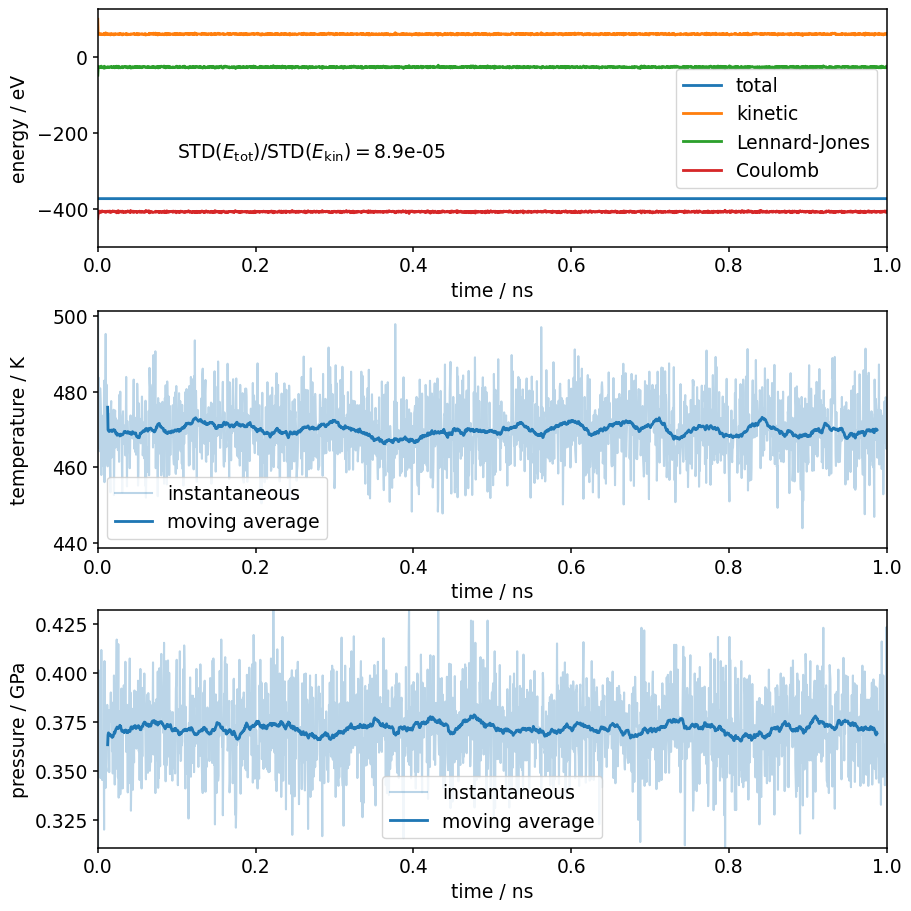

In [6]:
outdir_plots = BASERUNDIR / "plots"
outdir_plots.mkdir(exist_ok=True, parents=True)

ensemblename = "NVE"

fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(FIGSIZE_SINGLE[0], 3 * FIGSIZE_SINGLE[1]),
    # sharex=True,
    layout="constrained",
)

times_ns = log["time_ps"] / 10**3
xlim = (times_ns.min(), times_ns.max())

ax = axs[0]
ax.plot(times_ns, log["Etot_eV"], label="total")
ax.plot(times_ns, energies_kinetic, label="kinetic")
ax.plot(times_ns, energies_lj, label="Lennard-Jones")
ax.plot(times_ns, energies_coul, label="Coulomb")
ax.text(
    0.1,
    0.4,
    "$\mathrm{STD}(E_{\mathrm{tot}}) / \mathrm{STD}(E_{\mathrm{kin}})=$"
    + f"{energies_total_recomputed.std() / energies_kinetic.std():.2g}",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlim(xlim)
ylim = ax.get_ylim()
ax.set_ylim(ylim[0] - 0.085 * (ylim[1] - ylim[0]), ylim[1])
ax.set_xlabel("time / ns")
ax.set_ylabel("energy / eV")
ax.legend(loc="center right")

ax = axs[1]
plot_values_along_traj(
    ax,
    times=times_ns,
    values=log["temp_K"],
    ylabel="temperature / K",
)
ax.set_xlim(xlim)
ax.set_xlabel("time / ns")

ax = axs[2]
plot_values_along_traj(
    ax,
    times=times_ns,
    values=-log["stress_GPa"][:, :3].mean(axis=1),
    ylabel="pressure / GPa",
)
ax.set_xlim(xlim)
ax.set_xlabel("time / ns")

fig.align_ylabels()

filename_without_suffix = "results" + "_" + ensemblename
for suffix in ("png", "pdf"):
    fig.savefig(outdir_plots / (filename_without_suffix + "." + suffix))
plt.show()

# NVT

In [7]:
BASERUNDIR = Path("NVT/")


trajfile = BASERUNDIR / "out" / "md.traj"
logfile = BASERUNDIR / "out" / "md.log"

traj = ase.io.read(trajfile, index=":")
traj = fold_trajectory(traj)
log = read_logfile_ase(logfile, stress=True)

In [8]:
with open(BASERUNDIR / "md_setup_info.json", "r") as f:
    md_setup_info = json.load(f)

target_temperature_K = md_setup_info["temp_K"]

snapshot_interval_ps = log["time_ps"][-1] / (len(traj) - 1)

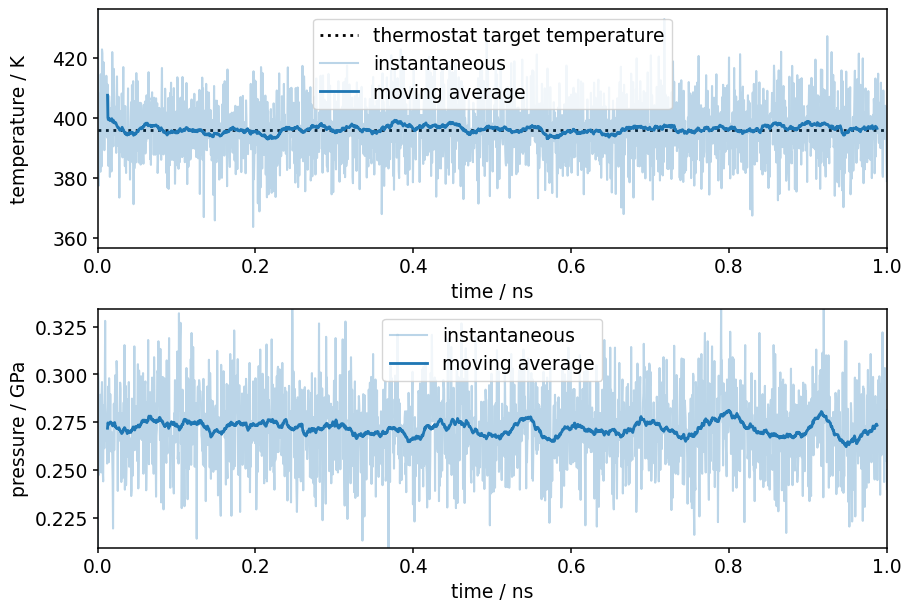

In [9]:
outdir_plots = BASERUNDIR / "plots"
outdir_plots.mkdir(exist_ok=True, parents=True)

ensemblename = "NVT"

times_ns = log["time_ps"] / 10**3
xlim = (times_ns.min(), times_ns.max())

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(FIGSIZE_SINGLE[0], 2 * FIGSIZE_SINGLE[1]),
    layout="constrained",
)

ax = axs[0]
plot_values_along_traj(
    ax,
    times=times_ns,
    values=log["temp_K"],
    ylabel="temperature / K",
    ref_value=target_temperature_K,
    ref_label="thermostat target temperature",
)
ax.set_xlim(xlim)
ax.set_xlabel("time / ns")

ax = axs[1]
plot_values_along_traj(
    ax,
    times=times_ns,
    values=-log["stress_GPa"][:, :3].mean(axis=1),
    ylabel="pressure / GPa",
)
ax.set_xlim(xlim)
ax.set_xlabel("time / ns")

fig.align_ylabels()

filename_without_suffix = "results" + "_" + ensemblename
for suffix in ("png", "pdf"):
    fig.savefig(outdir_plots / (filename_without_suffix + "." + suffix))
plt.show()

# NPT-temperature-ramp

In [10]:
import itertools
from natsort import natsorted

In [11]:
BASERUNDIR = Path("NPT-temperature-ramp/")

trajs_by_segment = []
logs_by_segment = []

for segmentdir in natsorted((BASERUNDIR / "out").iterdir()):
    print(segmentdir)

    traj_current_segment = ase.io.read(segmentdir / "md.traj", index=":")
    traj_current_segment = fold_trajectory(traj_current_segment)
    log_current_segment = read_logfile_ase(segmentdir / "md.log", stress=True)

    trajs_by_segment.append(traj_current_segment)
    logs_by_segment.append(log_current_segment)

NPT-temperature-ramp/out/0
NPT-temperature-ramp/out/1
NPT-temperature-ramp/out/2
NPT-temperature-ramp/out/3
NPT-temperature-ramp/out/4
NPT-temperature-ramp/out/5
NPT-temperature-ramp/out/6
NPT-temperature-ramp/out/7
NPT-temperature-ramp/out/8
NPT-temperature-ramp/out/9
NPT-temperature-ramp/out/10
NPT-temperature-ramp/out/11
NPT-temperature-ramp/out/12
NPT-temperature-ramp/out/13
NPT-temperature-ramp/out/14
NPT-temperature-ramp/out/15
NPT-temperature-ramp/out/16
NPT-temperature-ramp/out/17
NPT-temperature-ramp/out/18
NPT-temperature-ramp/out/19
NPT-temperature-ramp/out/20
NPT-temperature-ramp/out/21
NPT-temperature-ramp/out/22
NPT-temperature-ramp/out/23
NPT-temperature-ramp/out/24
NPT-temperature-ramp/out/25
NPT-temperature-ramp/out/26
NPT-temperature-ramp/out/27
NPT-temperature-ramp/out/28
NPT-temperature-ramp/out/29


In [12]:
with open(BASERUNDIR / "md_setup_info.json", "r") as f:
    md_setup_info = json.load(f)

range_of_temps_K = onp.array(md_setup_info["range_of_temps_K"])
target_pressure_GPa = md_setup_info["pressure_GPa"]
snapshot_interval_ps = md_setup_info["loginterval_fs"] / 10**3

segment_start_stop_inds = onp.cumsum(
    [0] + [len(log["time_ps"]) for log in logs_by_segment]
)
n_snapshots = segment_start_stop_inds[-1]

In [13]:
log = {"time_ps": onp.arange(n_snapshots) * snapshot_interval_ps}
for key in ["Etot_eV", "Epot_eV", "Ekin_eV", "temp_K", "stress_GPa"]:
    log[key] = onp.concatenate([log[key] for log in logs_by_segment])

traj = list(itertools.chain(*trajs_by_segment))
sidelengths_along_traj = onp.array([atoms.cell.cellpar()[0] for atoms in traj])

In [14]:
from ase.visualize import view

view(traj)

<Popen: returncode: None args: ['/home/florian/anaconda3/envs/msmjax_rev/bin...>

## Get "safe" cell-size limits in order to include in plot

In [15]:
def _get_cell_size_lims(
    cutoff_lvl_0: float,
    n_gridpoints_lvl_1: int,
    stencil_size_lvl_1: int,
    lower_spacing_thresh: float,
):
    sidelength_lo_stencils = (2 * n_gridpoints_lvl_1 * cutoff_lvl_0) / (
        stencil_size_lvl_1 + 1
    )
    sidelength_lo_mic = cutoff_lvl_0 / 2

    sidelength_hi = n_gridpoints_lvl_1 * lower_spacing_thresh

    return max(sidelength_lo_stencils, sidelength_lo_mic), sidelength_hi


def get_cell_size_limits(
    params: MSMParams, lower_spacing_thresh: float
) -> tuple[float, float]:
    sidelength_lo, sidelength_hi = _get_cell_size_lims(
        cutoff_lvl_0=params.cutoffs[0],
        n_gridpoints_lvl_1=params.grid_shapes[1][0],
        stencil_size_lvl_1=params.stencil_extents_from_center[1][0],
        lower_spacing_thresh=lower_spacing_thresh,
    )
    return sidelength_lo, sidelength_hi

In [16]:
params_baseline = MSMParams.load_json(Path("NVT/") / "msm_params.json")
params_safety = MSMParams.load_json(BASERUNDIR / "msm_params.json")

safe_lims_baseline = get_cell_size_limits(params_baseline, SIGMA_ANGSTROM)
safe_lims_safety = get_cell_size_limits(params_safety, SIGMA_ANGSTROM)

In [17]:
sidelength_NVT = ase.io.read("NVT/out/md.traj").cell.cellpar()[0]
max_expansion_percent_baseline = (
    safe_lims_baseline[1] / sidelength_NVT - 1.0
) * 100
max_expansion_percent_safety = (
    safe_lims_safety[1] / sidelength_NVT - 1.0
) * 100

print("Maximum side-length expansions relative to inital side length:")
print(f"- Baseline settings: {max_expansion_percent_baseline:.0f} %")
print(f"- Extended settings: {max_expansion_percent_safety:.0f} %")

Maximum side-length expansions relative to inital side length:
- Baseline settings: 14 %
- Extended settings: 52 %


## Plot

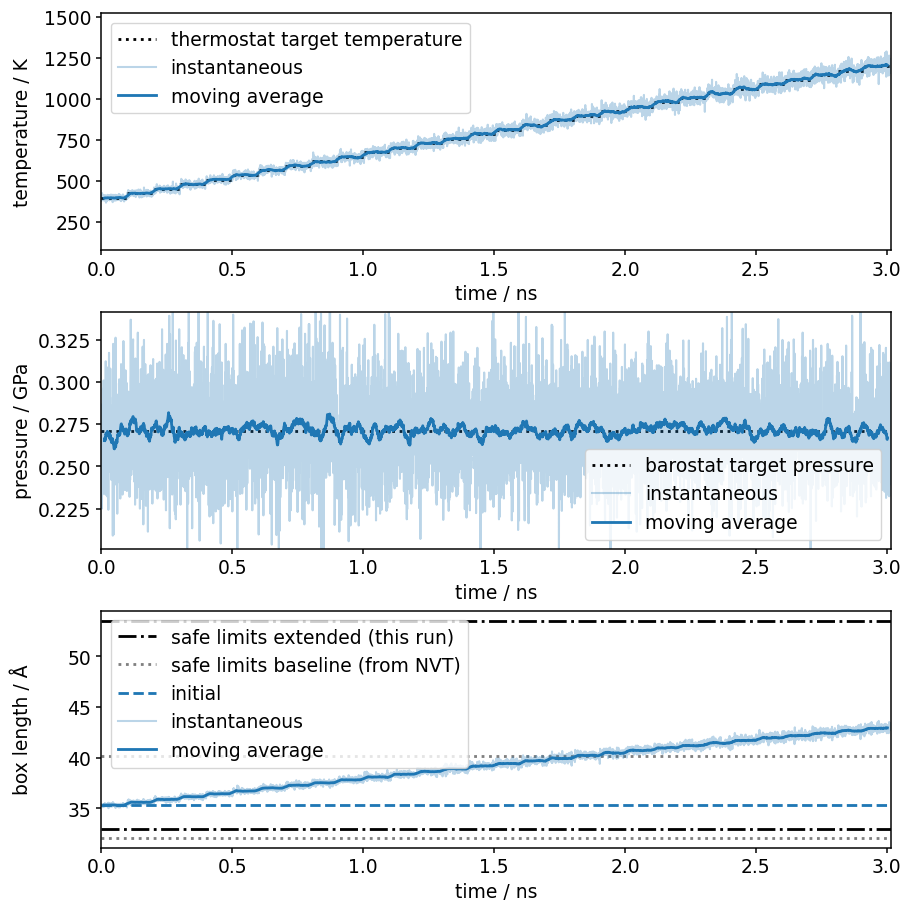

In [18]:
outdir_plots = BASERUNDIR / "plots"
outdir_plots.mkdir(exist_ok=True, parents=True)

ensemblename = "NPT"

times_ns = log["time_ps"] / 10**3
xlim = (times_ns.min(), times_ns.max())

fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(FIGSIZE_SINGLE[0], 3 * FIGSIZE_SINGLE[1]),
    layout="constrained",
)

ax = axs[0]
for i, (start, stop) in enumerate(
    zip(segment_start_stop_inds[:-1], segment_start_stop_inds[1:])
):
    time_start = log["time_ps"][start] / 10**3
    time_stop = log["time_ps"][stop - 1] / 10**3
    temp = range_of_temps_K[i]
    ax.plot(
        [time_start, time_stop],
        [temp, temp],
        color="black",
        linestyle=":",
        label="thermostat target temperature" if i == 0 else "",
    )
plot_values_along_traj(
    ax,
    times=log["time_ps"] / 10**3,
    values=log["temp_K"],
    ylabel="temperature / K",
)
ax.set_xlim(xlim)
ax.set_xlabel("time / ns")

ax = axs[1]
plot_values_along_traj(
    ax,
    times=log["time_ps"] / 10**3,
    values=-log["stress_GPa"][:, :3].mean(axis=1),
    ylabel="pressure / GPa",
    ref_value=target_pressure_GPa,
    ref_label="barostat target pressure",
)
ax.set_xlim(xlim)
ax.set_xlabel("time / ns")

ax = axs[2]
kwargs_safety = {"color": "black", "linestyle": "-.", "color": "black"}
kwargs_baseline = {"color": "black", "linestyle": ":", "color": "gray"}
ax.axhline(
    safe_lims_safety[0],
    label="safe limits extended (this run)",
    **kwargs_safety,
)
ax.axhline(safe_lims_safety[1], **kwargs_safety)
ax.axhline(
    safe_lims_baseline[0],
    **kwargs_baseline,
    label="safe limits baseline (from NVT)",
)
ax.axhline(safe_lims_baseline[1], **kwargs_baseline)
ax.axhline(sidelength_NVT, label="initial", linestyle="--")
plot_values_along_traj(
    ax,
    times=log["time_ps"] / 10**3,
    values=sidelengths_along_traj,
    ylabel="box length / Å",
)
ax.set_xlim(xlim)
ylim = (
    min(safe_lims_baseline[0], safe_lims_safety[0]) - 1.0,
    max(safe_lims_baseline[1], safe_lims_safety[1]) + 1.0,
)
ax.set_ylim(ylim)
ax.set_xlabel("time / ns")

fig.align_ylabels()

filename_without_suffix = "results" + "_" + ensemblename
for suffix in ("png", "pdf"):
    fig.savefig(outdir_plots / (filename_without_suffix + "." + suffix))
plt.show()